In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from data.combine_timetable import combine_timetables
from data.timetable import load_gold, save_gold


In [2]:
n_freight_trains = 178

passenger = load_gold('passenger')
freight   = load_gold('freight', n_trains=n_freight_trains)

# Validatie
overlap = set(passenger['TRAIN_NO']) & set(freight['TRAIN_NO'])
print(f"Overlappende TRAIN_NO: {overlap if overlap else 'geen'}")

combined = combine_timetables(n_freight_trains)
print(combined['TRAIN_TYPE'].value_counts())
print(f"ENTRY_SECONDS range: {combined['ENTRY_SECONDS'].min():.0f}s — {combined['ENTRY_SECONDS'].max():.0f}s")

Overlappende TRAIN_NO: geen
TRAIN_TYPE
IC         6158
L          3275
freight     722
EURST       324
INT         189
ICE         126
Name: count, dtype: int64
ENTRY_SECONDS range: 0s — 87056s


In [3]:
combined.head()

,SECTION,SOURCE,TARGET,PLANNED_ENTRY,PLANNED_EXIT,TRAIN_NO,TYPE,TRAIN_TYPE,PERIOD,DYNAMICS,ENTRY_SECONDS,EXIT_SECONDS
0,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,2025-01-01 21:23:00,2025-01-01 21:26:00,10,SOURCE,ICE,EVENING,ACC-BR,76863,77043
1,BRUSSEL-NOORD -- platform 3,BRUSSEL-NOORD,BRUSSEL-NOORD,2025-01-01 21:26:00,2025-01-01 21:28:00,10,WITHIN-STATION-DWELL,ICE,EVENING,0-0,77043,77163
2,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,BRUSSEL-NOORD,BRUSSEL-CONGRES,2025-01-01 21:28:00,2025-01-01 21:30:00,10,BETWEEN-STATION,ICE,EVENING,ACC-0,77163,77283
3,BRUSSEL-CONGRES -- platform 1,BRUSSEL-CONGRES,BRUSSEL-CONGRES,2025-01-01 21:30:00,2025-01-01 21:30:01,10,WITHIN-STATION-PASSING,ICE,EVENING,0-0,77283,77284
4,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,BRUSSEL-CENTRAAL,2025-01-01 21:30:01,2025-01-01 21:31:00,10,BETWEEN-STATION,ICE,EVENING,0-0,77284,77343


In [4]:
save_gold(combined, source='combined', n_trains=n_freight_trains)

Opgeslagen (combined): 1206 treinen, 10794 segmenten → /Users/ddw/Desktop/Rescheduling/data/gold/combined/178


In [5]:
import sys
sys.path.insert(0, "/Users/ddw/Desktop/Rescheduling")

import pandas as pd
from data.timetable import load_gold

# Laad combined timetable
df = load_gold('combined', n_trains=182)

# Inspecteer de twee conflicterende treinen
train_ids = [2076, 3228]

for tid in train_ids:
    subset = df[df['TRAIN_NO'] == tid].copy()
    subset = subset.sort_values('ENTRY_SECONDS')
    print(f"\n{'='*70}")
    print(f"TREIN {tid} — {len(subset)} segmenten")
    print(f"{'='*70}")
    print(subset[[
        'SECTION', 'SOURCE', 'TARGET', 'TYPE',
        'PLANNED_ENTRY', 'PLANNED_EXIT',
        'ENTRY_SECONDS', 'EXIT_SECONDS',
        'TRAIN_TYPE', 'DYNAMICS'
    ]].to_string(index=False))

# Welke segmenten delen ze?
segs_2076 = set(df[df['TRAIN_NO'] == 2076]['SECTION'])
segs_3228 = set(df[df['TRAIN_NO'] == 3228]['SECTION'])
shared = segs_2076 & segs_3228

print(f"\n{'='*70}")
print(f"Gedeelde segmenten: {shared}")

if shared:
    print(f"\nTijden op gedeelde segmenten:")
    for seg in sorted(shared):
        row_2076 = df[(df['TRAIN_NO'] == 2076) & (df['SECTION'] == seg)]
        row_3228 = df[(df['TRAIN_NO'] == 3228) & (df['SECTION'] == seg)]
        if not row_2076.empty and not row_3228.empty:
            print(f"\n  Segment: {seg}")
            print(f"  2076: entry={row_2076['ENTRY_SECONDS'].values[0]}s "
                  f"exit={row_2076['EXIT_SECONDS'].values[0]}s")
            print(f"  3228: entry={row_3228['ENTRY_SECONDS'].values[0]}s "
                  f"exit={row_3228['EXIT_SECONDS'].values[0]}s")
            diff = abs(row_2076['ENTRY_SECONDS'].values[0] - row_3228['ENTRY_SECONDS'].values[0])
            print(f"  Verschil entry: {diff}s")

# Check ook het blokkerende segment
print(f"\n{'='*70}")
print(f"Segment '50:JETTE-BOCKSTAEL' in timetable van 3228:")
seg_info = df[(df['TRAIN_NO'] == 3228) & (df['SECTION'] == '50:JETTE-BOCKSTAEL')]
if not seg_info.empty:
    print(seg_info[['SECTION', 'TYPE', 'ENTRY_SECONDS', 'EXIT_SECONDS']].to_string(index=False))
else:
    print("  Niet gevonden in timetable van 3228")

print(f"\nSegment '50:JETTE-BOCKSTAEL' in timetable van 2076:")
seg_info = df[(df['TRAIN_NO'] == 2076) & (df['SECTION'] == '50:JETTE-BOCKSTAEL')]
if not seg_info.empty:
    print(seg_info[['SECTION', 'TYPE', 'ENTRY_SECONDS', 'EXIT_SECONDS']].to_string(index=False))
else:
    print("  Niet gevonden in timetable van 2076")


TREIN 2076 — 13 segmenten
                                 SECTION              SOURCE              TARGET                   TYPE       PLANNED_ENTRY        PLANNED_EXIT  ENTRY_SECONDS  EXIT_SECONDS TRAIN_TYPE DYNAMICS
            50:SINT-AGATHA-BERCHEM-JETTE SINT-AGATHA-BERCHEM               JETTE                 SOURCE 2025-01-01 06:35:00 2025-01-01 06:38:00          23583         23763          L   ACC-BR
                     JETTE -- platform 1               JETTE               JETTE   WITHIN-STATION-DWELL 2025-01-01 06:38:00 2025-01-01 06:39:00          23763         23823          L      0-0
                      50:JETTE-BOCKSTAEL               JETTE           BOCKSTAEL        BETWEEN-STATION 2025-01-01 06:39:00 2025-01-01 06:41:00          23823         23943          L   ACC-BR
                 BOCKSTAEL -- platform 1           BOCKSTAEL           BOCKSTAEL   WITHIN-STATION-DWELL 2025-01-01 06:41:00 2025-01-01 06:43:00          23943         24063          L      0-0
        

Gevonden segmenten: 16
SECTION: 25:BRUSSEL-NOORD-SCHAARBEEK


,count,mean,std,median
TRAIN_TYPE,,,,
IC,71,180.845070,7.120690,180.0
L,33,183.636364,14.538351,180.0
freight,79,234.000000,0.000000,234.0


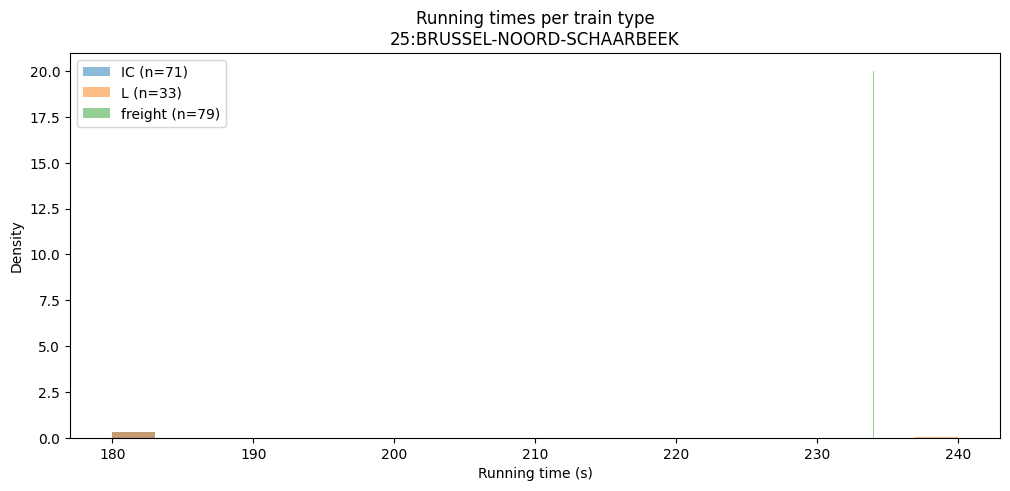

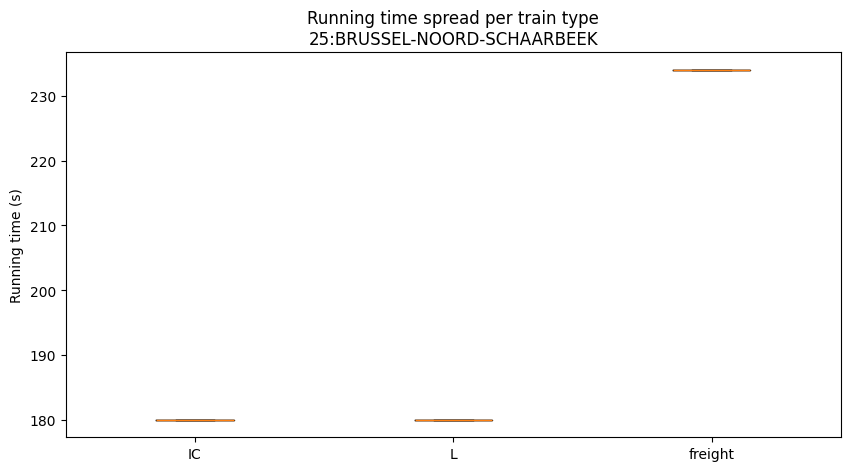

SECTION: 0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK


,count,mean,std,median
TRAIN_TYPE,,,,
L,61,60.00000,0.000000,60.0
IC,116,101.37931,27.878511,120.0


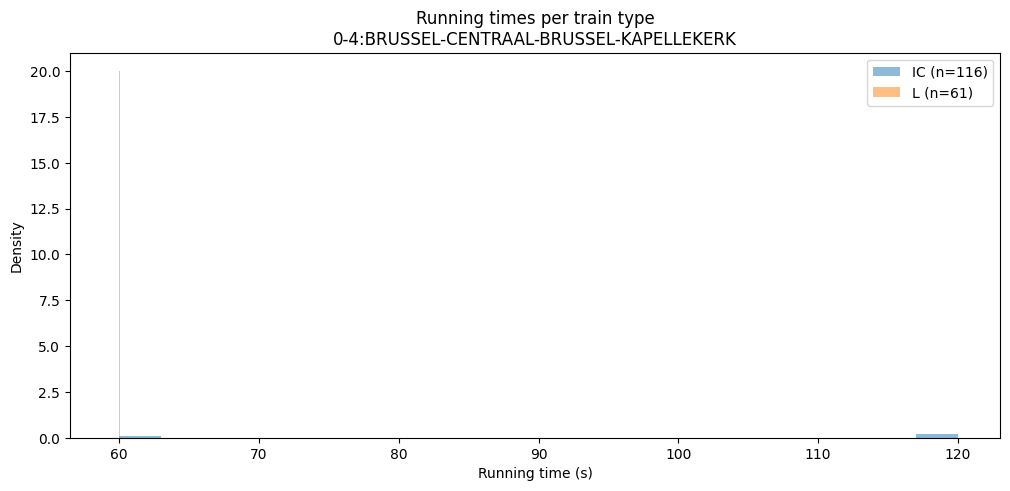

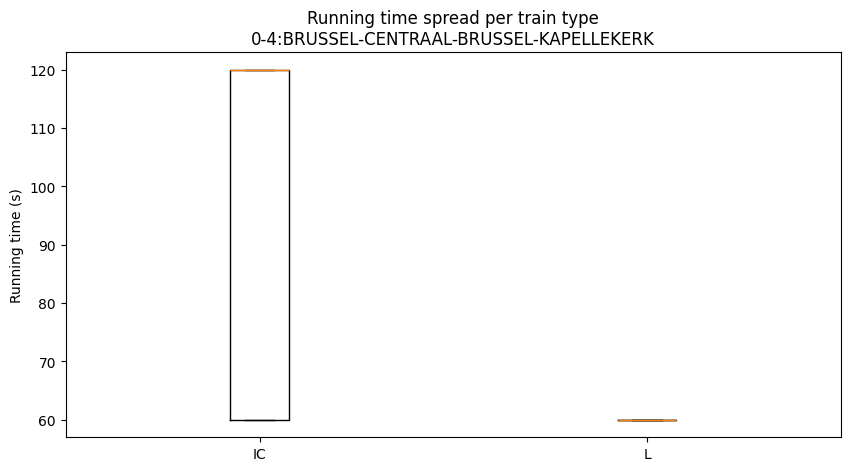

SECTION: 0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL


,count,mean,std,median
TRAIN_TYPE,,,,
L,61,60.000000,7.81025,59.0
IC,116,118.482759,5.57086,119.0


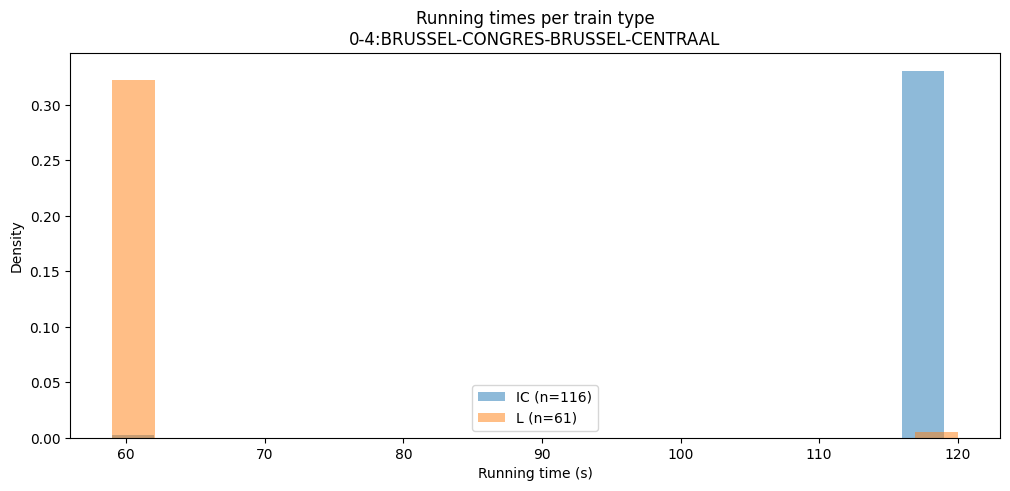

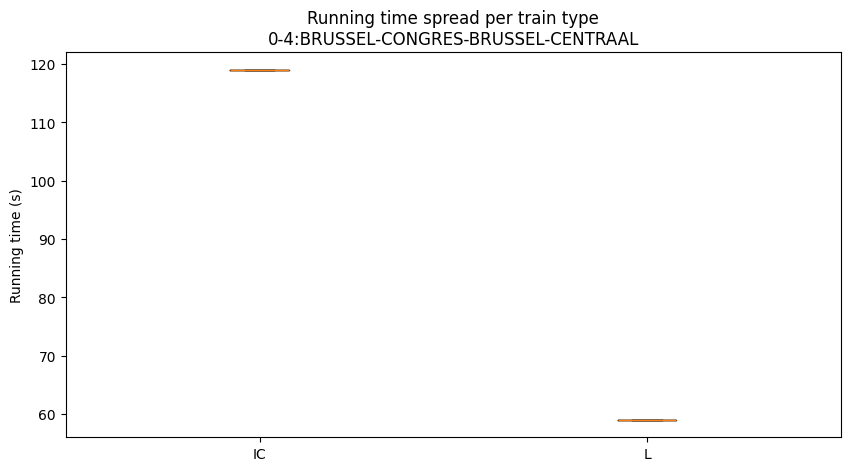

SECTION: 0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID


,count,mean,std,median
TRAIN_TYPE,,,,
IC,116,137.62069,27.878511,119.0
L,61,179.00000,0.000000,179.0


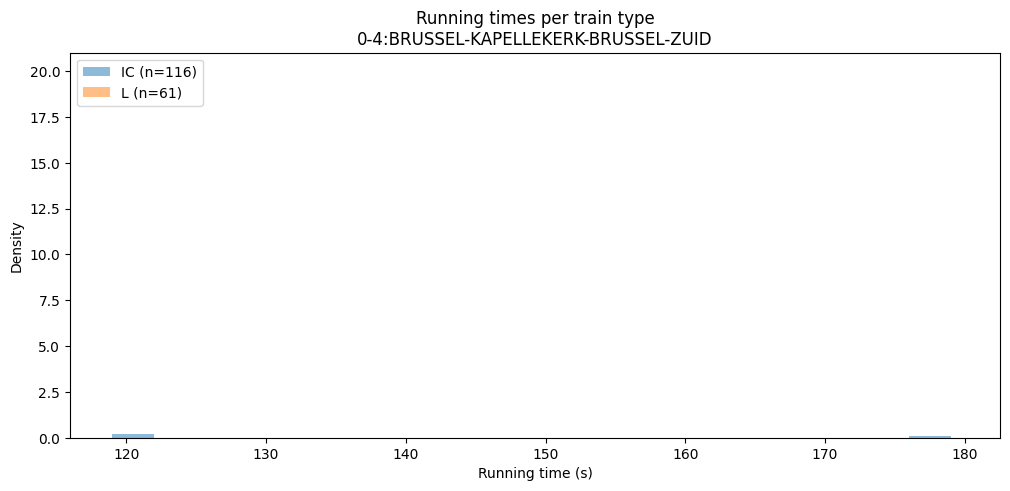

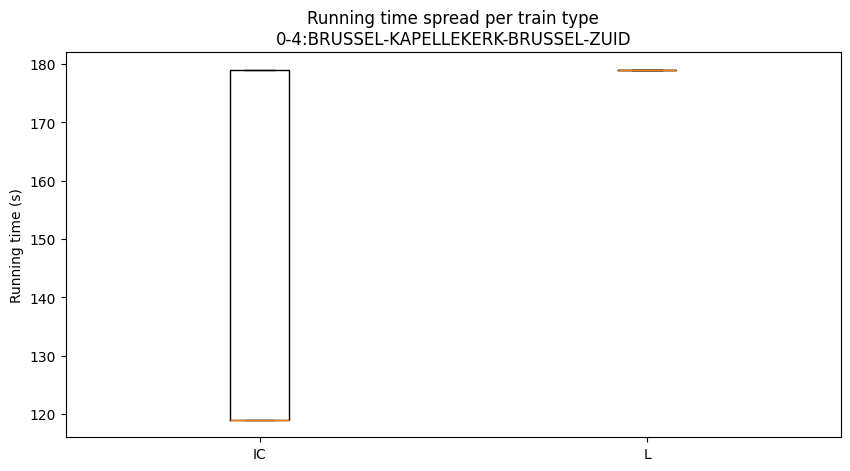

SECTION: 0-4:BRUSSEL-NOORD-BRUSSEL-CONGRES


,count,mean,std,median
TRAIN_TYPE,,,,
L,61,119.180328,6.401844,120.0
IC,114,120.526316,5.619515,120.0


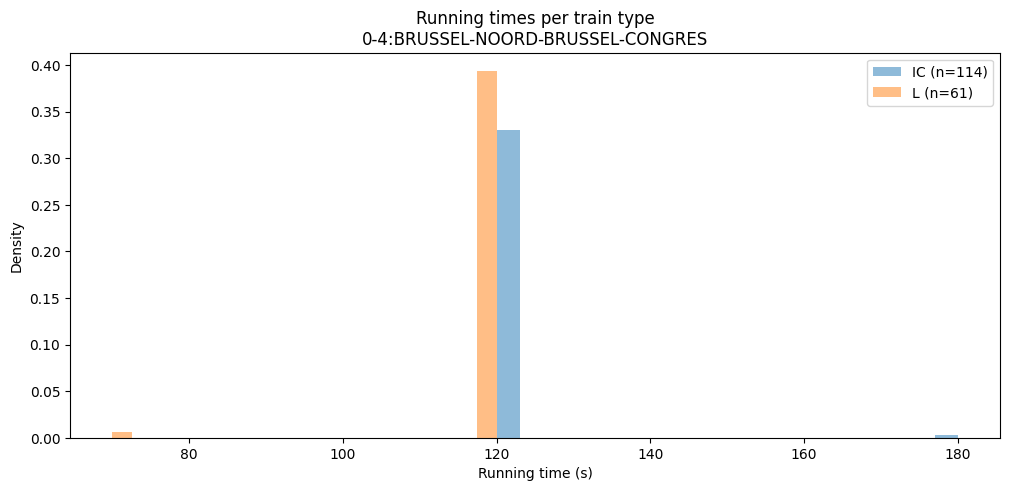

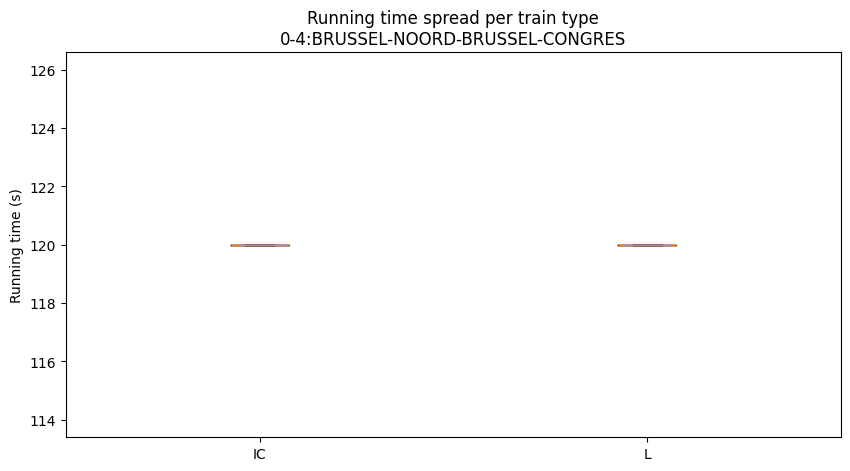

In [6]:
# =============================================================================
# Vergelijk running times tussen train types op meerdere segmenten
# =============================================================================

import matplotlib.pyplot as plt

# Running time toevoegen
df['RUNNING_TIME'] = (
    df['EXIT_SECONDS'] - df['ENTRY_SECONDS']
)

# Enkel between-station
between = df[df['TYPE'] == 'BETWEEN-STATION'].copy()

# Zoek segmenten met meerdere train types
candidate_sections = []

for section, subset in between.groupby('SECTION'):

    counts = subset.groupby('TRAIN_TYPE').size()

    # minstens 2 types
    if len(counts) < 2:
        continue

    # minstens 30 observaties per type
    if (counts >= 30).all():

        score = counts.sum()

        candidate_sections.append({
            'section': section,
            'n_types': len(counts),
            'n_obs': score
        })

# Sorteer op meeste data + meeste types
candidate_sections = sorted(
    candidate_sections,
    key=lambda x: (x['n_types'], x['n_obs']),
    reverse=True
)

print(f"Gevonden segmenten: {len(candidate_sections)}")

# ============================================================================
# Visualiseer top N segmenten
# ============================================================================

TOP_N = 5

for info in candidate_sections[:TOP_N]:

    section = info['section']

    print("=" * 80)
    print(f"SECTION: {section}")
    print("=" * 80)

    segment_df = between[
        between['SECTION'] == section
    ].copy()

    # ------------------------------------------------------------------------
    # Stats
    # ------------------------------------------------------------------------

    stats = (
        segment_df.groupby('TRAIN_TYPE')['RUNNING_TIME']
        .agg(['count', 'mean', 'std', 'median'])
        .sort_values('mean')
    )

    display(stats)

    # ------------------------------------------------------------------------
    # Histogram
    # ------------------------------------------------------------------------

    plt.figure(figsize=(12, 5))

    for ttype in sorted(segment_df['TRAIN_TYPE'].unique()):

        subset = segment_df[
            segment_df['TRAIN_TYPE'] == ttype
        ]['RUNNING_TIME']

        plt.hist(
            subset,
            bins=20,
            alpha=0.5,
            density=True,
            label=f"{ttype} (n={len(subset)})"
        )

    plt.xlabel("Running time (s)")
    plt.ylabel("Density")
    plt.title(f"Running times per train type\n{section}")
    plt.legend()
    plt.show()

    # ------------------------------------------------------------------------
    # Boxplot
    # ------------------------------------------------------------------------

    plot_data = []
    labels = []

    for ttype in sorted(segment_df['TRAIN_TYPE'].unique()):

        subset = segment_df[
            segment_df['TRAIN_TYPE'] == ttype
        ]['RUNNING_TIME']

        plot_data.append(subset)
        labels.append(ttype)

    plt.figure(figsize=(10, 5))

    plt.boxplot(
        plot_data,
        tick_labels=labels,
        showfliers=False
    )

    plt.ylabel("Running time (s)")
    plt.title(f"Running time spread per train type\n{section}")

    plt.show()

In [7]:
print(df.columns)

Index(['SECTION', 'SOURCE', 'TARGET', 'PLANNED_ENTRY', 'PLANNED_EXIT',
       'TRAIN_NO', 'TYPE', 'TRAIN_TYPE', 'PERIOD', 'DYNAMICS', 'ENTRY_SECONDS',
       'EXIT_SECONDS', 'RUNNING_TIME'],
      dtype='str')
